# How well do jobs and skills pay for Data Scientist?

#### Methodology
1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Scientist
3. Visualize for highest paying skills and most demanded skills


## Import Libraries and Data

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Salary Distribution by Job Title

Filter our data to only include salary values from the India.

In [2]:
df_IND = df[df['job_country'] == 'India'].dropna(subset= 'salary_year_avg')

df_IND

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1209,Machine Learning Engineer,Computer Vision Developer (R&D),"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-02-18 13:12:30,False,False,India,year,79200.0,NaN,Bosch Group,"[python, opencv, tensorflow, pytorch, keras, m...","{'libraries': ['opencv', 'tensorflow', 'pytorc..."
2022,Data Engineer,Data Engineer - SQL (Power BI),India,via Ai-Jobs.net,Full-time,False,India,2023-10-31 13:09:54,False,False,India,year,156500.0,NaN,Gartner,"[java, t-sql, sql, azure, power bi, dax, notion]","{'analyst_tools': ['power bi', 'dax'], 'async'..."
2785,Data Engineer,Staff Software Engineer - Data Engineering (Ja...,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-05-26 13:13:28,False,False,India,year,147500.0,NaN,Zscaler,"[java, nosql, neo4j, redshift, aws, spring, sp...","{'analyst_tools': ['excel'], 'cloud': ['redshi..."
3190,Senior Data Engineer,Senior Big Data DevOps & Deployment Engineer,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-07-07 13:14:21,False,False,India,year,79200.0,NaN,ServiceNow,"[sql, perl, bash, groovy, python, shell, redis...","{'analyst_tools': ['tableau'], 'cloud': ['azur..."
3930,Data Scientist,Lead Data Scientist,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-12-12 13:27:33,False,False,India,year,114516.0,NaN,Boeing,"[python, r, c++, tensorflow, tableau]","{'analyst_tools': ['tableau'], 'libraries': ['..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783733,Senior Data Scientist,Senior Data Scientist,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-06-27 06:12:11,False,False,India,year,157500.0,NaN,Publicis Groupe,"[aws, spark, tableau, cognos, excel, powerpoin...","{'analyst_tools': ['tableau', 'cognos', 'excel..."
784033,Data Analyst,Recruitment Data Analyst,"Mumbai, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-06-07 06:10:15,False,False,India,year,111175.0,NaN,Framestore,"[power bi, tableau]","{'analyst_tools': ['power bi', 'tableau']}"
784768,Data Scientist,SR. DATA SCIENTIST,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-01-03 06:25:25,False,False,India,year,157500.0,NaN,Optiv,"[r, python, sql, databricks, power bi]","{'analyst_tools': ['power bi'], 'cloud': ['dat..."
785395,Data Engineer,Senior Consultant - Tech Consulting -Azure Dat...,India,via Ai-Jobs.net,Full-time,False,India,2023-12-19 06:10:41,False,False,India,year,64800.0,NaN,EY,"[sql, python, azure, databricks, spark, power ...","{'analyst_tools': ['power bi', 'tableau', 'qli..."


Create a list of the main job_titles in our dataset and filter our dataframe to only contain these job titles.

In [3]:
job_title = df_IND['job_title_short'].value_counts().index[:6].to_list()

# filter the df for the top 6 job titles
df_IND_top6 = df_IND[df_IND['job_title_short'].isin(job_title)]

# order the job titles by median salary
job_order = df_IND_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index.tolist()

job_order
job_title

['Data Engineer',
 'Data Analyst',
 'Data Scientist',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Software Engineer']

## Plot Salary Distributions

Plot the top 6 job titles salary distributions using a box plot.

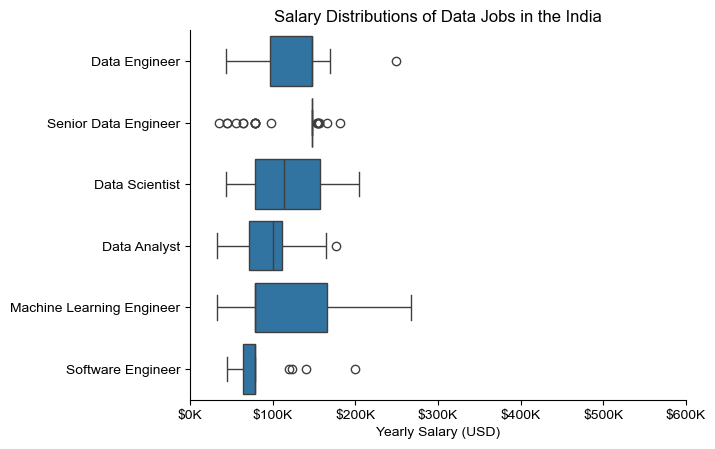

In [4]:
sns.boxplot(data = df_IND_top6, x = 'salary_year_avg', y = 'job_title_short', order=job_order)
sns.set_theme(style='ticks')
sns.despine()

# this is all the same
plt.title('Salary Distributions of Data Jobs in the India')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000) 
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

## Investigate Median Salary Vs Skill for Data Scientist

Filters the original dataset to only get rows where the job title is 'Data Scientist' and the country is 'India', to create a new DataFrame `df_DS_IND`. Drop NaN values from the 'salary_year_avg' column. Then it uses the `explode` method on the `job_skills` column to create a new row in the DataFrame for each skill associated with a job. Finally, it displays the first five entries of the `salary_year_avg` and `job_skills` columns.

In [13]:
# Only get data Scientist jobs in the IND
df_DS_IND = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Scientist')].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_DS_IND = df_DS_IND.dropna(subset ='salary_year_avg')



,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
3930,Data Scientist,Lead Data Scientist,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-12-12 13:27:33,False,False,India,year,114516.0,NaN,Boeing,"[python, r, c++, tensorflow, tableau]","{'analyst_tools': ['tableau'], 'libraries': ['..."
9143,Data Scientist,Manager - Data Science,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-05-12 13:28:49,False,False,India,year,79200.0,NaN,BitGo,"[sql, tableau]","{'analyst_tools': ['tableau'], 'programming': ..."
16358,Data Scientist,Data Scientist,India,via Ai-Jobs.net,Full-time,False,India,2023-07-19 13:12:35,False,False,India,year,157500.0,NaN,Silent Eight,"[python, sql, bash, postgresql, pandas, pyspar...","{'async': ['jira', 'confluence'], 'databases':..."
27440,Data Scientist,Data Scientist,"Pune, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-06-15 13:27:09,False,False,India,year,157500.0,NaN,"AppZen, Inc.","[python, r]","{'programming': ['python', 'r']}"
30999,Data Scientist,Data Scientist,"Noida, Uttar Pradesh, India",via Ai-Jobs.net,Full-time,False,India,2023-07-07 13:14:07,False,False,India,year,157500.0,NaN,HashiCorp,"[python, aws, numpy, pandas, tensorflow, pytor...","{'cloud': ['aws'], 'libraries': ['numpy', 'pan..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762560,Data Scientist,Data Scientist,"Pune, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-06-12 20:29:35,False,False,India,year,70000.0,NaN,Avaloq,"[python, r, sql, java, mysql, sql server, reds...","{'analyst_tools': ['tableau', 'power bi'], 'cl..."
762634,Data Scientist,Data Modeller,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-02-23 20:30:17,True,False,India,year,64800.0,NaN,Capco,"[sql, python, scala, hadoop]","{'libraries': ['hadoop'], 'programming': ['sql..."
768729,Data Scientist,Lead Data Modeler/Developer for Business Analy...,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-02-04 01:33:21,False,False,India,year,79200.0,NaN,Bosch Group,[sql],{'programming': ['sql']}
770989,Data Scientist,"Data Scientist –ML, DL, Python","Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-07-21 01:12:02,False,False,India,year,157500.0,NaN,Capco,"[python, r, sql, t-sql, sql server, snowflake,...","{'analyst_tools': ['tableau', 'power bi', 'qli..."


In [18]:
df_DS_IND = df_DS_IND.explode('job_skills')

df_DS_IND[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
3930,114516.0,python
3930,114516.0,r
3930,114516.0,c++
3930,114516.0,tensorflow
3930,114516.0,tableau


## Determine The Highest Paid Skills and Most Demanded Skills

Gets the top ten highest-paying skills for Data Scientist by calculating the median salary for each skill listed in the `df_DS_IND`. It groups the data by job skills, computes the median salary, sorts these values in descending order by median, and then selects the top 10. This is then formatted into a new DataFrame (`df_DS_top_pay`) with a reset index and a renamed salary column labeled 'median_salary'.

In [23]:
df_DS_IND_top = df_DS_IND.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median', ascending=False).head(10)

df_DS_IND_top

,count,median
job_skills,,
shell,3,170500.0
express,1,170500.0
looker,1,166419.5
databricks,4,164037.5
bigquery,2,160000.0
go,6,157500.0
haskell,1,157500.0
sql server,7,157500.0
jira,3,157500.0


Calculates the count and median salary for each skill in `df_DS_IND`. It groups the data by `job_skills`, aggregates it to find the count and median salary for each skill, and then sorts the results by count in descending order by count. It re-sorts this subset by median salary in descending order.

In [32]:
df_DS_skills = df_DS_IND.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count', ascending= False)

df_DS_skills = df_DS_skills.head(10).sort_values(by = 'median', ascending = False)

df_DS_skills

,count,median
job_skills,,
azure,15,157500.00
pytorch,10,157500.00
python,64,152500.00
tensorflow,16,136008.00
r,30,129758.00
sql,49,113500.00
tableau,19,113500.00
aws,20,103550.00
spark,23,93600.00


Creates two horizontal bar charts: 
1. Displays the highest paid skills 
2. Shows the most in demand skills 

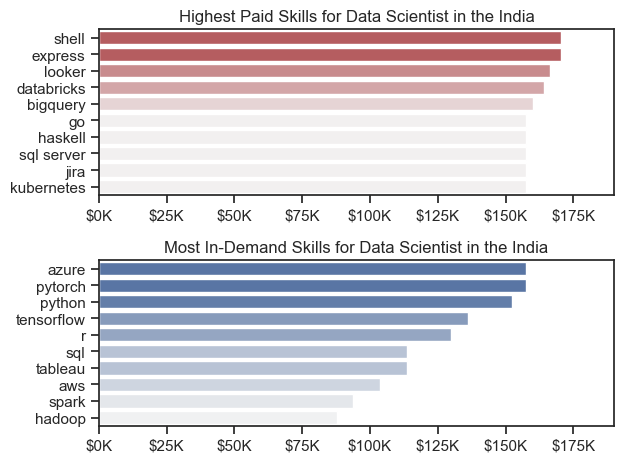

In [50]:
fig, ax = plt.subplots(2,1)

# Top 10 Highest Paid Skills for  Data Scientist
sns.barplot(data = df_DS_IND_top, x = 'median', y = df_DS_IND_top.index, ax= ax[0], hue ='median', palette = 'light:r', legend = False)
ax[0].set_title('Highest Paid Skills for Data Scientist in the India')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_xlim(0, 190000)

ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda i,_: f'${int(i/1000)}K'))

# Top 10 Most In-Demand skills for Data Scientist
sns.barplot(data = df_DS_skills, x = 'median', y = df_DS_skills.index, ax= ax[1], hue ='median', palette = 'light:b',legend = False)
ax[1].set_title('Most In-Demand Skills for Data Scientist in the India')
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].set_xlim(0, 190000)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda i,_: f'${int(i/1000)}K'))

sns.set_theme(style='ticks')
fig.tight_layout()

